# Project - Airline AI Assistant

We'll now bring together what we've learned to make an AI Customer Support assistant for an Airline

In [5]:
# imports

import os
import json
from dotenv import load_dotenv
from openai import OpenAI
import gradio as gr
import sqlite3

In [ ]:
# Initialization

load_dotenv(override=True)

openai_api_key = os.getenv('OPENAI_API_KEY')
if openai_api_key:
    print(f"OpenAI API Key exists and begins {openai_api_key[:8]}")
else:
    print("OpenAI API Key not set")

gemini_api_key = os.getenv('GOOGLE_API_KEY')
if gemini_api_key:
    print(f"Gemini API Key exists and begins {gemini_api_key[:8]}")
else:    
    print("Gemini API Key not set")

openrouter_api_key = os.getenv('OPENROUTER_API_KEY')
if openrouter_api_key:
    print(f"OpenRouter API Key exists and begins {openrouter_api_key[:8]}")
else:
    print("OpenRouter API Key not set")
    
# MODEL = "gpt-4.1-mini"
# openai = OpenAI()

# MODEL = "gemma4:e4b"
# openai = OpenAI(base_url='http://localhost:11434/v1', api_key='ollama')

# MODEL = "gemini-3.5-flash"
# openai = OpenAI(base_url='https://generativelanguage.googleapis.com/v1beta/openai/', api_key=gemini_api_key)

MODEL = "nvidia/nemotron-3-nano-30b-a3b:free"
openai = OpenAI(base_url='https://openrouter.ai/api/v1', api_key=openrouter_api_key)

DB = "prices.db"

OpenAI API Key exists and begins sk-or-v1
Gemini API Key exists and begins AQ.Ab8RN
OpenRouter API Key exists and begins sk-or-v1


In [7]:
system_message = """
You are a helpful assistant for an Airline called FlightAI.
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""

In [8]:
def get_ticket_price(city):
    print(f"DATABASE TOOL CALLED: Getting price for {city}", flush=True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('SELECT price FROM prices WHERE city = ?', (city.lower(),))
        result = cursor.fetchone()
        return f"Ticket price to {city} is ${result[0]}" if result else "No price data available for this city"

In [9]:
get_ticket_price("Paris")

DATABASE TOOL CALLED: Getting price for Paris


'Ticket price to Paris is $899.0'

In [10]:
price_function = {
    "name": "get_ticket_price",
    "description": "Get the price of a return ticket to the destination city.",
    "parameters": {
        "type": "object",
        "properties": {
            "destination_city": {
                "type": "string",
                "description": "The city that the customer wants to travel to",
            },
        },
        "required": ["destination_city"],
        "additionalProperties": False
    }
}
tools = [{"type": "function", "function": price_function}]
tools

[{'type': 'function',
  'function': {'name': 'get_ticket_price',
   'description': 'Get the price of a return ticket to the destination city.',
   'parameters': {'type': 'object',
    'properties': {'destination_city': {'type': 'string',
      'description': 'The city that the customer wants to travel to'}},
    'required': ['destination_city'],
    'additionalProperties': False}}}]

In [13]:

def chat(message, history):
    history = [{"role": h["role"], "content": h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=MODEL, messages=messages)
    return response.choices[0].message.content

gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


In [11]:
def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses = handle_tool_calls(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    
    return response.choices[0].message.content

In [12]:
def handle_tool_calls(message):
    responses = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses

In [8]:
gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


## A bit more about what Gradio actually does:

1. Gradio constructs a frontend Svelte app based on our Python description of the UI
2. Gradio starts a server built upon the Starlette web framework listening on a free port that serves this React app
3. Gradio creates backend routes for our callbacks, like chat(), which calls our functions

And of course when Gradio generates the frontend app, it ensures that the the Submit button calls the right backend route.

That's it!

It's simple, and it has a result that feels magical.

# Let's go multi-modal!!

We can use DALL-E-3, the image generation model behind GPT-4o, to make us some images

Let's put this in a function called artist.

### Price alert: each time I generate an image it costs about 4 cents - don't go crazy with images!

In [9]:
# Some imports for handling images

import base64
from io import BytesIO
from PIL import Image

In [10]:
def artist(city):
    image_response = openai.images.generate(
            model="nvidia/llama-nemotron-rerank-vl-1b-v2:free",
            prompt=f"An image representing a vacation in {city}, showing tourist spots and everything unique about {city}, in a vibrant pop-art style",
            size="1024x1024",
            n=1,
            response_format="b64_json",
        )
    image_base64 = image_response.data[0].b64_json
    image_data = base64.b64decode(image_base64)
    return Image.open(BytesIO(image_data))

  0%|          | 0/4 [00:00<?, ?it/s]

c:\Adri\Work\Personal Projects\llm_engineering\.venv\Lib\site-packages\diffusers\pipelines\stable_diffusion_xl\pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


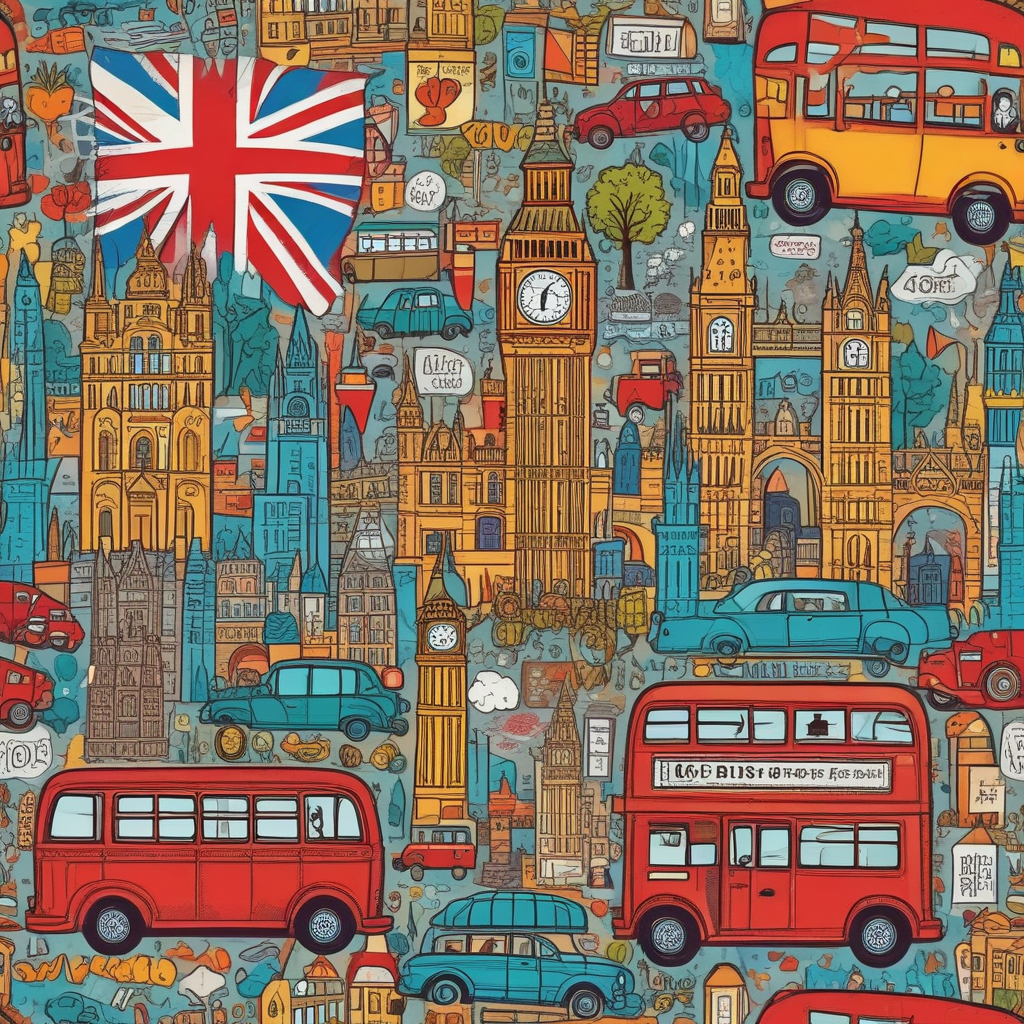

In [13]:
artist('London')

In [12]:
import base64
from io import BytesIO
import torch
from diffusers import StableDiffusionPipeline
from PIL import Image

In [ ]:
# # Use a raw string (r"") so Windows backslashes don't break your code
# MODEL_PATH = r"C:\Github\stable-diffusion-webui\models\Stable-diffusion\v1-5-pruned-emaonly-fp16.safetensors"

# pipe = StableDiffusionPipeline.from_single_file(
#     MODEL_PATH,
#     torch_dtype=torch.float16,
#     variant="fp16",
#     local_files_only=True
# )
# pipe.enable_sequential_cpu_offload()
# # pipe.enable_model_cpu_offload()
# # pipe.to("cuda")

# def artist(city):
#     prompt = f"An image representing a vacation in {city}, showing tourist spots and everything unique about {city}, in a vibrant pop-art style"
    
#     # 3. Generate image using standard SD 1.5 generation configurations
#     local_image = pipe(
#         prompt=prompt,
#         num_inference_steps=20,  # Standard SD 1.5 needs ~20 steps to look good
#         guidance_scale=7.5,      # Standard classifier-free guidance
#         width=512,               # Strictly keep at 512 for SD 1.5 base models
#         height=512               # Strictly keep at 512 for SD 1.5 base models
#     ).images[0]
    
#     # 4. Process back to PIL output (Matches your original app logic)
#     buffered = BytesIO()
#     local_image.save(buffered, format="PNG")
#     image_base64 = base64.b64encode(buffered.getvalue())
    
#     image_data = base64.b64decode(image_base64)
#     return Image.open(BytesIO(image_data))

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

AttributeError: 'CLIPTextModel' object has no attribute 'text_model'

In [1]:
import torch
from diffusers import StableDiffusionXLPipeline, UNet2DConditionModel, EulerDiscreteScheduler
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file

base = "stabilityai/stable-diffusion-xl-base-1.0"
repo = "ByteDance/SDXL-Lightning"
ckpt = "sdxl_lightning_4step_unet.safetensors" # Use the correct ckpt for your step setting!

#Set HF_Token environment variable to your Hugging Face token before running this code.
# os.environ["HF_TOKEN"] = "your-huggingface-token"

# Load model.
unet = UNet2DConditionModel.from_config(base, subfolder="unet").to("cuda", torch.float16)
unet.load_state_dict(load_file(hf_hub_download(repo, ckpt), device="cuda"))
pipe = StableDiffusionXLPipeline.from_pretrained(base, unet=unet, torch_dtype=torch.float16, variant="fp16").to("cuda")

# This moves components to GPU only when needed, capping VRAM usage around 4-6GB
pipe.enable_model_cpu_offload()

# This splits the heavy VAE image generation into smaller tiles to prevent 8GB/4GB crashes
pipe.enable_vae_tiling()

# Ensure sampler uses "trailing" timesteps.
pipe.scheduler = EulerDiscreteScheduler.from_config(pipe.scheduler.config, timestep_spacing="trailing")


c:\Adri\Work\Personal Projects\llm_engineering\.venv\Lib\site-packages\diffusers\configuration_utils.py:282: FutureWarning: It is deprecated to pass a pretrained model name or path to `from_config`.If you were trying to load a model, please use <class 'diffusers.models.unets.unet_2d_condition.UNet2DConditionModel'>.load_config(...) followed by <class 'diffusers.models.unets.unet_2d_condition.UNet2DConditionModel'>.from_config(...) instead. Otherwise, please make sure to pass a configuration dictionary instead. This functionality will be removed in v1.0.0.
  deprecate("config-passed-as-path", "1.0.0", deprecation_message, standard_warn=False)
c:\Adri\Work\Personal Projects\llm_engineering\.venv\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

c:\Adri\Work\Personal Projects\llm_engineering\.venv\Lib\site-packages\diffusers\pipelines\pipeline_utils.py:2294: FutureWarning: `enable_vae_tiling` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_tiling()` on a `StableDiffusionXLPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_tiling()`.
  deprecate(


In [2]:
def artist(city):
    prompt = f"An image representing a vacation in {city}, showing tourist spots and everything unique about {city}, in a vibrant pop-art style"
    return pipe(prompt, num_inference_steps=4, guidance_scale=0).images[0]

  0%|          | 0/4 [00:00<?, ?it/s]

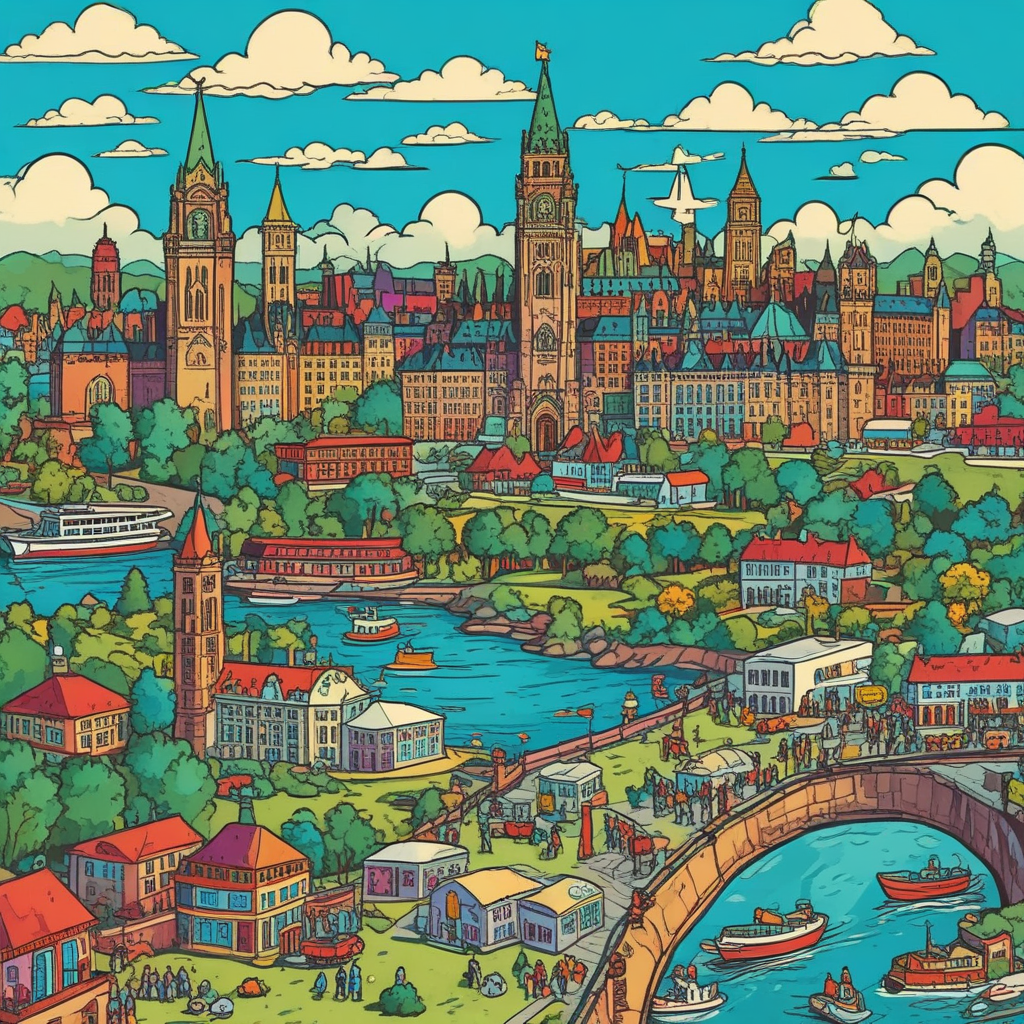

In [4]:
artist('Ottawa')

In [ ]:
def talker(message):
    response = openai.audio.speech.create(
      model="gpt-4o-mini-tts",
      voice="onyx",    # Also, try replacing onyx with alloy or coral
      input=message
    )
    return response.content

In [5]:
from kokoro import KPipeline
from IPython.display import display, Audio
import soundfile as sf
import torch
pipeline = KPipeline(lang_code='a')
text = '''
[Kokoro](/kˈOkəɹO/) is an open-weight TTS model with 82 million parameters. Despite its lightweight architecture, it delivers comparable quality to larger models while being significantly faster and more cost-efficient. With Apache-licensed weights, [Kokoro](/kˈOkəɹO/) can be deployed anywhere from production environments to personal projects.
'''
generator = pipeline(text, voice='af_heart')
for i, (gs, ps, audio) in enumerate(generator):
    print(i, gs, ps)
    display(Audio(data=audio, rate=24000, autoplay=i==0))
    # sf.write(f'{i}.wav', audio, 24000)

config.json:   0%|          | 0.00/2.35k [00:00<?, ?B/s]

c:\Adri\Work\Personal Projects\llm_engineering\.venv\Lib\site-packages\torch\nn\modules\rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
c:\Adri\Work\Personal Projects\llm_engineering\.venv\Lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


kokoro-v1_0.pth:   0%|          | 0.00/327M [00:00<?, ?B/s]

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


voices/af_heart.pt:   0%|          | 0.00/523k [00:00<?, ?B/s]

0 Kokoro is an open-weight TTS model with 82 million parameters. Despite its lightweight architecture, it delivers comparable quality to larger models while being significantly faster and more cost-efficient. With Apache-licensed weights, Kokoro can be deployed anywhere from production environments to personal projects. kˈOkəɹO ɪz ɐn ˈOpᵊnwˌAt tˌitˌiˈɛs mˈɑdᵊl wɪð ˈATi tˈu mˈɪljᵊn pəɹˈæməTəɹz. dəspˈIt ɪts lˈItwˌAt ˈɑɹkətˌɛkʧəɹ, ɪt dəlˈɪvəɹz kˈɑmpəɹəbᵊl kwˈɑləTi tə lˈɑɹʤəɹ mˈɑdᵊlz wˌIl bˈiɪŋ səɡnˈɪfəkəntli fˈæstəɹ ænd mˈɔɹ kˈɔstəfˌɪʃənt. wˌɪð əpˌæʧilˈIsᵊnst wˈAts, kˈOkəɹO kæn bi dəplˈYd ˈɛniwˌɛɹ fɹʌm pɹədˈʌkʃən ənvˈIɹənmᵊnts tə pˈɜɹsᵊnəl pɹˈɑʤˌɛkts.


In [6]:
generator

<generator object KPipeline.__call__ at 0x0000017D9DC74860>

In [14]:
# Create a function to handle the TTS generation and playback using the Kokoro model
from kokoro import KPipeline
from IPython.display import display, Audio
import soundfile as sf
import numpy as np

def talker(message):
    pipeline = KPipeline(lang_code='a')
    generator = pipeline(text=message, voice='af_heart')

    audio_outputs = []
    for i, (gs, ps, audio) in enumerate(generator):
        print(i, gs, ps)
        # display(Audio(data=audio, rate=24000, autoplay=i==0))
        audio_outputs.append(audio)

    if not audio_outputs:
        return None
    
    # Concatenate audio outputs if there are multiple segments
    full_audio = np.concatenate(audio_outputs)
    return (24000, full_audio)

message = "Hello, how are you?"
talker(message)

c:\Adri\Work\Personal Projects\llm_engineering\.venv\Lib\site-packages\torch\nn\modules\rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
c:\Adri\Work\Personal Projects\llm_engineering\.venv\Lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


0 Hello, how are you? həlˈO, hˌW ɑɹ ju?


(24000,
 array([-5.0802288e-07,  2.9402551e-07, -1.3173202e-07, ...,
        -1.1211671e-07,  5.2738613e-08, -2.3621608e-07],
       shape=(40800,), dtype=float32))

## Let's bring this home:

1. A multi-modal AI assistant with image and audio generation
2. Tool callling with database lookup
3. A step towards an Agentic workflow


In [ ]:
def chat(history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    cities = []
    image = None

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses, cities = handle_tool_calls_and_return_cities(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    reply = response.choices[0].message.content
    history += [{"role":"assistant", "content":reply}]

    voice = talker(reply)

    if cities:
        image = artist(cities[0])
    
    return history, voice, image


In [ ]:
def handle_tool_calls_and_return_cities(message):
    responses = []
    cities = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            cities.append(city)
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses, cities

In [ ]:
def chat(history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    cities = []
    image = None

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses, cities = handle_tool_calls_and_return_cities(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    reply = response.choices[0].message.content
    history += [{"role":"assistant", "content":reply}]

    voice = talker(reply)

    if cities:
        image = artist(cities[0])
    
    return history, voice, image


def handle_tool_calls_and_return_cities(message):
    responses = []
    cities = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            cities.append(city)
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses, cities

## The 3 types of Gradio UI

`gr.Interface` is for standard, simple UIs

`gr.ChatInterface` is for standard ChatBot UIs

`gr.Blocks` is for custom UIs where you control the components and the callbacks

In [ ]:
def chat(history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    cities = []
    image = None

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses, cities = handle_tool_calls_and_return_cities(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    reply = response.choices[0].message.content
    history += [{"role":"assistant", "content":reply}]

    voice = talker(reply)

    if cities:
        image = artist(cities[0])
    
    return history, voice, image


def handle_tool_calls_and_return_cities(message):
    responses = []
    cities = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            cities.append(city)
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses, cities

# Callbacks (along with the chat() function above)

def put_message_in_chatbot(message, history):
        return "", history + [{"role":"user", "content":message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500, type="messages")
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

# Hooking up events to callbacks

    message.submit(put_message_in_chatbot, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot, audio_output, image_output]
    )

ui.launch(inbrowser=True, auth=("ed", "bananas"))

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14784\212618303.py:51: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot = gr.Chatbot(height=500, type="messages")


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


c:\Adri\Work\Personal Projects\llm_engineering\.venv\Lib\site-packages\torch\nn\modules\rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
c:\Adri\Work\Personal Projects\llm_engineering\.venv\Lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


0 Hello! How can I assist you with your flight booking today? həlˈO! hˌW kæn ˌI əsˈɪst ju wɪð jʊɹ flˈIt bˈʊkɪŋ tədˈA?


c:\Adri\Work\Personal Projects\llm_engineering\.venv\Lib\site-packages\gradio\processing_utils.py:688: UserWarning: Trying to convert audio automatically from float32 to 16-bit int format.
  warnings.warn(warning.format(data.dtype))


...

DATABASE TOOL CALLED: Getting price for New York


c:\Adri\Work\Personal Projects\llm_engineering\.venv\Lib\site-packages\torch\nn\modules\rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
c:\Adri\Work\Personal Projects\llm_engineering\.venv\Lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


0 I’m sorry, but I don’t have price information for New York at this time. ˌIm sˈɔɹi, bˌʌt ˌI dˈOnt hæv pɹˈIs ˌɪnfəɹmˈAʃən fɔɹ nˈu jˈɔɹk æt ðɪs tˈIm.


  0%|          | 0/4 [00:00<?, ?it/s]

c:\Adri\Work\Personal Projects\llm_engineering\.venv\Lib\site-packages\diffusers\pipelines\stable_diffusion_xl\pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
c:\Adri\Work\Personal Projects\llm_engineering\.venv\Lib\site-packages\gradio\processing_utils.py:688: UserWarning: Trying to convert audio automatically from float32 to 16-bit int format.
  warnings.warn(warning.format(data.dtype))


# Exercises and Business Applications

Add in more tools - perhaps to simulate actually booking a flight. A student has done this and provided their example in the community contributions folder.

Next: take this and apply it to your business. Make a multi-modal AI assistant with tools that could carry out an activity for your work. A customer support assistant? New employee onboarding assistant? So many possibilities! Also, see the week2 end of week Exercise in the separate Notebook.

<table style="margin: 0; text-align: left;">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/thankyou.jpg" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#090;">I have a special request for you</h2>
            <span style="color:#090;">
                My editor tells me that it makes a HUGE difference when students rate this course on Udemy - it's one of the main ways that Udemy decides whether to show it to others. If you're able to take a minute to rate this, I'd be so very grateful! And regardless - always please reach out to me at ed@edwarddonner.com if I can help at any point.
            </span>
        </td>
    </tr>
</table>